# Overview DATA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv("train.csv")
data.head()

,Id,Year,Age,School,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position,Drafted
0,0,2011,21.0,Lehigh,1.9050,140.160042,5.39,59.69,29.0,251.46,7.91,4.94,offense,offensive_lineman,OG,1.0
1,1,2011,24.0,Abilene Christian,1.8288,87.089735,4.31,101.60,16.0,332.74,NaN,NaN,offense,backs_receivers,WR,1.0
2,2,2018,21.0,Colorado St.,1.8542,92.986436,4.51,91.44,10.0,309.88,6.95,4.37,offense,backs_receivers,WR,1.0
3,3,2010,21.0,East Carolina,1.9304,148.778297,5.09,76.20,39.0,254.00,8.12,4.71,defense,defensive_lineman,DT,1.0
4,4,2016,21.0,California,1.8796,92.079251,4.64,78.74,NaN,281.94,7.13,4.20,offense,backs_receivers,WR,1.0


In [3]:
print(data.shape)

(2781, 16)


In [4]:
data.drop("Id",axis=1,inplace=True)
data.head()

,Year,Age,School,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position,Drafted
0,2011,21.0,Lehigh,1.9050,140.160042,5.39,59.69,29.0,251.46,7.91,4.94,offense,offensive_lineman,OG,1.0
1,2011,24.0,Abilene Christian,1.8288,87.089735,4.31,101.60,16.0,332.74,NaN,NaN,offense,backs_receivers,WR,1.0
2,2018,21.0,Colorado St.,1.8542,92.986436,4.51,91.44,10.0,309.88,6.95,4.37,offense,backs_receivers,WR,1.0
3,2010,21.0,East Carolina,1.9304,148.778297,5.09,76.20,39.0,254.00,8.12,4.71,defense,defensive_lineman,DT,1.0
4,2016,21.0,California,1.8796,92.079251,4.64,78.74,NaN,281.94,7.13,4.20,offense,backs_receivers,WR,1.0


In [5]:
data.drop("School",axis=1,inplace=True)

In [6]:
data.drop("Year",axis=1,inplace=True)

In [7]:
print(len(list(data["Position_Type"].unique())))
print(len(list(data["Player_Type"].unique())))

7
3


In [8]:
data.shape

(2781, 13)

In [9]:
data["Drafted"].value_counts()

Drafted
1.0    1803
0.0     978
Name: count, dtype: int64

In [10]:
data.head()

,Age,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position,Drafted
0,21.0,1.9050,140.160042,5.39,59.69,29.0,251.46,7.91,4.94,offense,offensive_lineman,OG,1.0
1,24.0,1.8288,87.089735,4.31,101.60,16.0,332.74,NaN,NaN,offense,backs_receivers,WR,1.0
2,21.0,1.8542,92.986436,4.51,91.44,10.0,309.88,6.95,4.37,offense,backs_receivers,WR,1.0
3,21.0,1.9304,148.778297,5.09,76.20,39.0,254.00,8.12,4.71,defense,defensive_lineman,DT,1.0
4,21.0,1.8796,92.079251,4.64,78.74,NaN,281.94,7.13,4.20,offense,backs_receivers,WR,1.0


In [11]:
len(list(data["Position"].unique()))

20

In [12]:
# age is very important so lets see the age of 1 and zero 
# BMI is very important too
# ratio btw Bench_Press / weight ( relative stregth ) src=GYM
# how std is far from the std of the sprint, vertical jump 

In [13]:
data.isna().sum()

Age                 435
Height                0
Weight                0
Sprint_40yd         145
Vertical_Jump       554
Bench_Press_Reps    721
Broad_Jump          581
Agility_3cone       970
Shuttle             912
Player_Type           0
Position_Type         0
Position              0
Drafted               0
dtype: int64

# High Corr 

In [14]:
num_cols=data.select_dtypes(include="number").columns

corr_data=data.loc[:,num_cols]

corr_matrix=corr_data.corr()


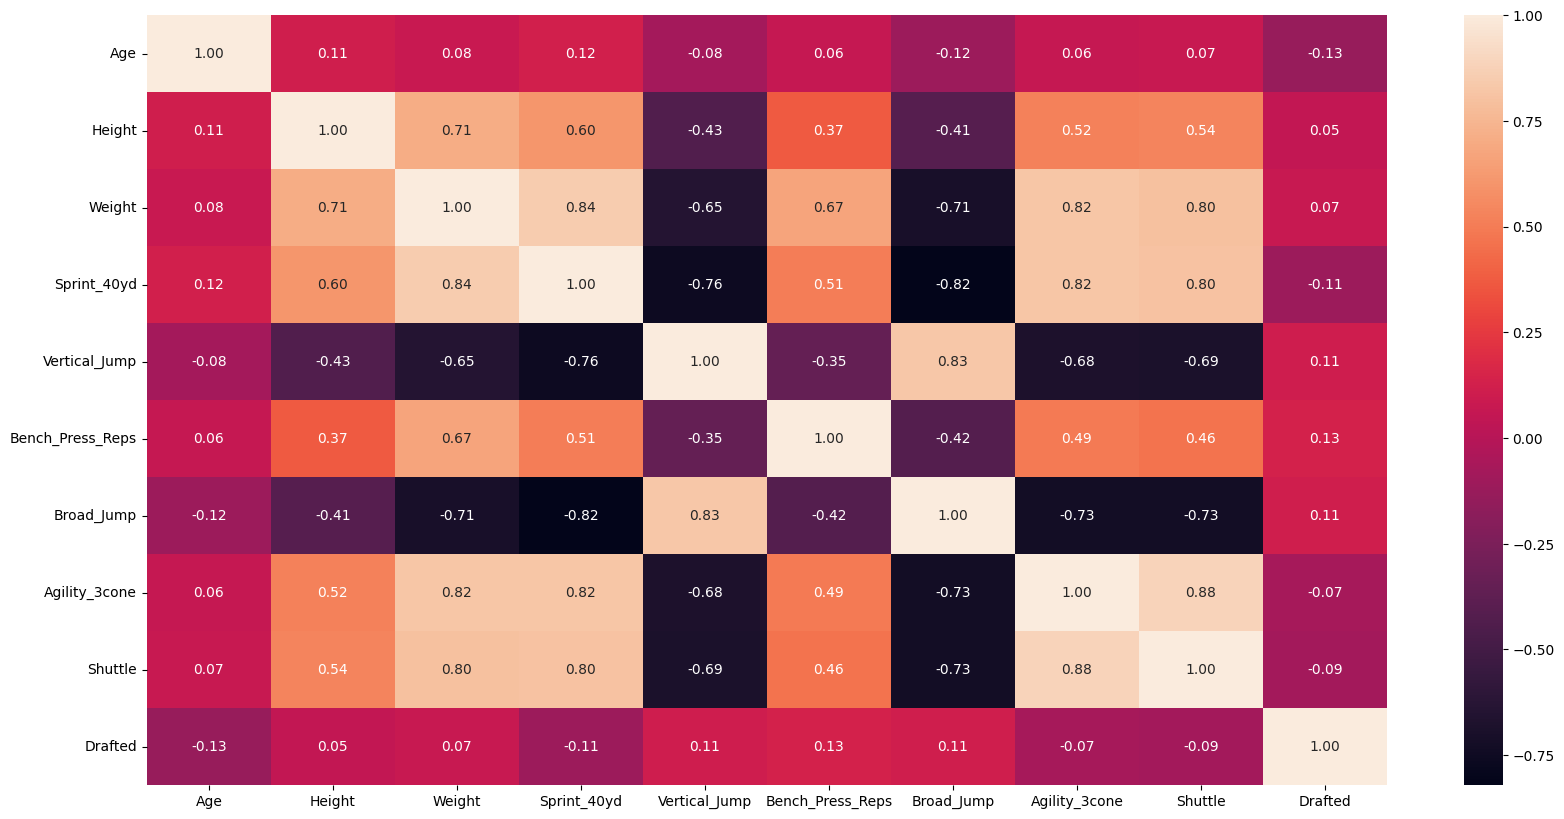

In [15]:
plt.figure(figsize=(20,10))
sns.heatmap(corr_matrix,fmt=".2f",annot=True,)
plt.show()

In [16]:
type(corr_matrix)

pandas.core.frame.DataFrame

In [17]:
abs_corr_matrix=corr_matrix.abs()
ones_matrix=np.ones(shape=abs_corr_matrix.shape).astype(bool)
lower_trig=np.tril(ones_matrix,k=-1)
lower_corr=abs_corr_matrix.where(lower_trig)
lower_corr=lower_corr.unstack()
lower_corr=lower_corr.dropna()

In [18]:
lower_corr

Age               Height              0.111377
                  Weight              0.082392
                  Sprint_40yd         0.122848
                  Vertical_Jump       0.078574
                  Bench_Press_Reps    0.064357
                  Broad_Jump          0.115926
                  Agility_3cone       0.061936
                  Shuttle             0.068932
                  Drafted             0.133055
Height            Weight              0.705727
                  Sprint_40yd         0.603278
                  Vertical_Jump       0.430196
                  Bench_Press_Reps    0.367146
                  Broad_Jump          0.408969
                  Agility_3cone       0.517658
                  Shuttle             0.535568
                  Drafted             0.046875
Weight            Sprint_40yd         0.844383
                  Vertical_Jump       0.647688
                  Bench_Press_Reps    0.671284
                  Broad_Jump          0.707087
             

In [19]:
sort_high_corr=lower_corr.sort_values(ascending=False)
sort_high_corr=sort_high_corr.reset_index()
sort_high_corr.columns=["first","second","corr"]
sort_high_corr
# Shuttle , Agility_3cone high accuracy with weight and they have many nan values so we can delete them and depend on the weight

,first,second,corr
0,Agility_3cone,Shuttle,0.879571
1,Weight,Sprint_40yd,0.844383
2,Vertical_Jump,Broad_Jump,0.828637
3,Sprint_40yd,Broad_Jump,0.820895
4,Weight,Agility_3cone,0.817706
5,Sprint_40yd,Agility_3cone,0.816042
6,Sprint_40yd,Shuttle,0.801723
7,Weight,Shuttle,0.796042
8,Sprint_40yd,Vertical_Jump,0.757027
9,Broad_Jump,Shuttle,0.729444


In [20]:
data_no_corr=data.drop(["Shuttle" , "Agility_3cone"],axis=1)
data_no_corr.shape

(2781, 11)

# Model for know the basic importance feature not the FINAL model

In [21]:
data_no_corr.isna().sum()

Age                 435
Height                0
Weight                0
Sprint_40yd         145
Vertical_Jump       554
Bench_Press_Reps    721
Broad_Jump          581
Player_Type           0
Position_Type         0
Position              0
Drafted               0
dtype: int64

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,StandardScaler,OrdinalEncoder
from sklearn.impute import SimpleImputer

In [23]:
data_x_first=data_no_corr.drop("Drafted",axis=1)
data_y_first=data_no_corr["Drafted"]

In [24]:
num_cols=data_x_first.select_dtypes("number").columns
cat_cols=data_x_first.select_dtypes("object").columns
print(num_cols)
print(cat_cols)

Index(['Age', 'Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump',
       'Bench_Press_Reps', 'Broad_Jump'],
      dtype='object')
Index(['Player_Type', 'Position_Type', 'Position'], dtype='object')


In [25]:
num_pipe=Pipeline(
    steps=[
        ("nan_num",SimpleImputer(strategy="median")),
        ("standardization",StandardScaler())
    ]
)
cat_pipe=Pipeline(
    steps=[
        ("nan_cat",SimpleImputer(strategy="most_frequent")),
        ("encoding",OrdinalEncoder(handle_unknown="use_encoded_value",unknown_value=-1))
    ],
)

In [26]:
col_transform=ColumnTransformer(
    transformers=[
        ("num_transform",num_pipe,num_cols),
        ("cat_transform",cat_pipe,cat_cols)
    ],verbose_feature_names_out=False
)

In [27]:
num_cols

Index(['Age', 'Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump',
       'Bench_Press_Reps', 'Broad_Jump'],
      dtype='object')

In [28]:
from sklearn.ensemble import RandomForestClassifier

data_pre=col_transform.fit_transform(data_x_first)

In [29]:
df_data_pre=pd.DataFrame(data_pre,columns=col_transform.get_feature_names_out())
df_data_pre.head()

,Age,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Player_Type,Position_Type,Position
0,-1.125851,0.467641,1.509980,2.156260,-2.491704,1.599565,-1.928488,1.0,5.0,10.0
1,2.260225,-0.666855,-1.103859,-1.542508,1.881513,-0.756766,1.887155,1.0,0.0,19.0
2,-1.125851,-0.288689,-0.813432,-0.857551,0.821339,-1.844303,0.814006,1.0,0.0,19.0
3,-1.125851,0.845807,1.934450,1.128824,-0.768921,3.412127,-1.809249,0.0,2.0,4.0
4,-1.125851,0.089476,-0.858113,-0.412329,-0.503878,-0.031741,-0.497622,1.0,0.0,19.0


In [30]:
rf_model=RandomForestClassifier(n_estimators=100)

from sklearn.model_selection import cross_val_score

In [31]:
scores=cross_val_score(rf_model,df_data_pre,data_y_first,cv=3)

In [32]:
scores

array([0.69579288, 0.70334412, 0.7162891 ])

In [33]:
rf_model.fit(df_data_pre,data_y_first)
im_features=rf_model.feature_importances_

In [34]:
df_im_feature=pd.DataFrame({
    "Names":data_x_first.columns,
    "Score":im_features
}).sort_values(by="Score",ascending=False)


In [35]:
df_im_feature

,Names,Score
3,Sprint_40yd,0.190485
2,Weight,0.180050
6,Broad_Jump,0.118585
4,Vertical_Jump,0.113341
5,Bench_Press_Reps,0.110561
1,Height,0.095727
0,Age,0.090845
9,Position,0.053848
7,Player_Type,0.025303
8,Position_Type,0.021254


In [36]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model.fit(df_data_pre,data_y_first)

xgb_importances = xgb_model.feature_importances_
feature_names=data_x_first.columns
xgb_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_importances
}).sort_values(by='Importance', ascending=False)

booster = xgb_model.get_booster()
booster.feature_names = list(feature_names)
gain_scores = booster.get_score(importance_type='gain')

xgb_gain_df = pd.DataFrame({
    'Feature': list(gain_scores.keys()),
    'Gain Score': list(gain_scores.values())
}).sort_values(by='Gain Score', ascending=False)

In [37]:
scores=cross_val_score(xgb_model,df_data_pre,data_y_first,cv=3)
scores

array([0.66990291, 0.6763754 , 0.68392665])

In [38]:
xgb_importance_df

,Feature,Importance
0,Age,0.234397
7,Player_Type,0.151063
8,Position_Type,0.108110
3,Sprint_40yd,0.096391
2,Weight,0.078274
5,Bench_Press_Reps,0.069418
6,Broad_Jump,0.068673
9,Position,0.066754
1,Height,0.064971
4,Vertical_Jump,0.061948


In [39]:
xgb_gain_df

,Feature,Gain Score
0,Age,4.795270
7,Player_Type,3.090426
8,Position_Type,2.211709
3,Sprint_40yd,1.971950
2,Weight,1.601323
5,Bench_Press_Reps,1.420147
6,Broad_Jump,1.404907
9,Position,1.365637
1,Height,1.329175
4,Vertical_Jump,1.267317


# Try on all the data

In [40]:
data_x=data.drop("Drafted",axis=1)
data_y=data["Drafted"]

In [41]:
num_cols=data_x.select_dtypes(include="number").columns
num_cols=data_x.select_dtypes(include="object").columns


In [42]:
data_x=col_transform.fit_transform(data_x)

In [43]:
scores=cross_val_score(rf_model,data_x,data_y,cv=5)
scores

array([0.68581688, 0.67805755, 0.70683453, 0.71942446, 0.69244604])

In [44]:
# Position is not important enough for the model

# Now Start Visualize

In [45]:
data_no_corr.head()

,Age,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Player_Type,Position_Type,Position,Drafted
0,21.0,1.9050,140.160042,5.39,59.69,29.0,251.46,offense,offensive_lineman,OG,1.0
1,24.0,1.8288,87.089735,4.31,101.60,16.0,332.74,offense,backs_receivers,WR,1.0
2,21.0,1.8542,92.986436,4.51,91.44,10.0,309.88,offense,backs_receivers,WR,1.0
3,21.0,1.9304,148.778297,5.09,76.20,39.0,254.00,defense,defensive_lineman,DT,1.0
4,21.0,1.8796,92.079251,4.64,78.74,NaN,281.94,offense,backs_receivers,WR,1.0
